In [33]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, precision_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import ADASYN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.stats import skew
import seaborn as sns
import pandas as pd
import numpy as np
import os

In [34]:
"""
Класс логистической регрессии был модифицирован и теперь метод fit возвращает список со значениями
функции ошибки (binary cross-entropy) на каждой итерации обучения.

Вы можете сравнивать графики функции ошибки для модели, обученной на `сырых данных` (пункт 1.1), и для модели,
обученной на трансформированных данных (данные из пункта 1.3), для анализа влияния трансформаций на динамику обучения модели
(ускорение обучения, ошибка ниже на первой итерации и т.д.).
"""

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def binary_cross_entropy(pred, label):
    return -np.mean(label * np.log(pred + 1e-6) + (1. - label) * np.log(1 - pred + 1e-6))


class LogisticRegression:
    def __init__(self, dim=2):
        rng = np.random.default_rng(seed=0)
        self.w = rng.normal(size=(dim, 1)) / np.sqrt(dim)
        self.b = np.zeros((1,))

    def predict(self, x, probs=False):
        # x - np.array размерности [N, dim]
        #     Массив входных признаков.
        assert x.shape[1] == self.w.shape[0], \
            "Размерность экземпляров данных не соответствует ожидаемой: " + \
            f"ожидалось x.shape[1]={self.w.shape[0]}, но было получено x.shape[1]={x.shape[1]}"
        x = x.dot(self.w) + self.b
        p = sigmoid(x)
        if probs:
            return p
        return np.array(p > 0.5).astype('int32')

    def fit(self, x, y, iters=300, lr=0.1):
        # x - np.array размерности [N, dim]
        #     Массив входных признаков.
        # y - np.array размернсоти [N]
        #     Массив меток (правильных ответов).
        assert len(x) == len(y), \
            "Количество экземпляров в массиве X не равно количеству меток в массиве Y. " + \
            f"Полученные размеры: len(X) = {len(x)}, len(Y) = {len(y)}."
        assert x.shape[1] == self.w.shape[0], \
            "Размерность экземпляров данных не соответствует ожидаемой: " + \
            f"ожидалось x.shape[1]={self.w.shape[0]}, но было получено x.shape[1]={x.shape[1]}"
        y = y.reshape(-1, 1)
        loss = []
        for i in range(iters):
            preds = self.predict(x, probs=True)
            self.w -= lr * x.T.dot(preds - y) / y.shape[0]
            self.b -= lr * np.mean(preds - y, axis=0)
            loss.append(binary_cross_entropy(preds, y))
        return loss

In [35]:
def load_data(folder_path):
    x_train = pd.read_csv(os.path.join(folder_path, 'x_train.csv'))
    y_train = pd.read_csv(os.path.join(folder_path, 'y_train.csv'))
    x_test = pd.read_csv(os.path.join(folder_path, 'x_test.csv'))
    y_test = pd.read_csv(os.path.join(folder_path, 'y_test.csv'))
    return x_train, y_train, x_test, y_test

In [49]:
x_train, y_train, x_test, y_test = load_data('lr3_dataset/')

In [37]:
x_train.head()

,statuses_count,followers_count,friends_count,favourites_count,listed_count,is_default_profile,is_profile_use_background_image,user_age,tweets_freq,followers_growth_rate,friends_growth_rate,favourites_growth_rate,listed_growth_rate,followers_friends_ratio,screen_name_length,num_digits_in_screen_name,length_of_name,num_digits_in_name,description_length
0,38278,19692,3289,40071,335,0,1,4278,8.947639,4.603086,0.768817,9.366760,0.078308,5.987230,10,0,11,0,136
1,97523,54632,3544,1563,1091,0,0,4583,21.279293,11.920576,0.773293,0.341043,0.238054,15.415350,13,2,13,2,156
2,13533,2835,1246,1217,95,0,1,4629,2.923526,0.612443,0.269173,0.262908,0.020523,2.275281,7,2,11,0,119
3,13159,13950,2009,9477,161,0,0,4256,3.091870,3.277726,0.472039,2.226739,0.037829,6.943753,14,0,14,0,108
4,34670,19234,544,6587,121,1,1,3280,10.570122,5.864024,0.165854,2.008232,0.036890,35.356618,6,0,16,0,159


В данной лабораторной работе будет практиковаться обработка данных на примере датасета для задачи распознавания ботов в социальной сети Твиттер. Класс 0 означает человек, класс 1 означает бот. `Обучите модель так, чтобы вероятность пропуска бота составляла менее 4% (данный порог может быть ослаблен в зависимости от общих результатов лабораторных). Значение метрики F1 должно быть не менее 0.95.`

Требование: использовать лишь 10 признаков (это могут быть либо сгенерированные признаки, либо отобранные).

Допускается коллаборация (использование подходов к обработке данных, придуманных другими студентами) при условии ссылки на автора подхода в комментариях к коду (фамилия и инициалы).

## 1.1 Обучение baseline модели

Указание: `в данном пункте не применяйте трансформации к данным за рамками указанных`. Это необходимо для того, чтобы вы могли проводить сравнение в дальнейшем для лучшего понимания влияния вашего подхода к обработке данных на качество модели. Обучение baseline модели - стандартная практика, что даёт вам минимально рабочую модель и при этом позволяет отслеживать ваш прогресс.

In [38]:
# Снизьте размерность данных одним из способов:
# 1. вручную отобрав 10 признаков
# 2. используя PCA (from sklearn.decomposition import PCA)
# Указание: не нормализуйте данные (min/max, mean/std и прочее).

pca_baseline = PCA(n_components=10, random_state=0)
X_train_pca_raw = pca_baseline.fit_transform(x_train)
X_test_pca_raw = pca_baseline.transform(x_test)

explained_variance = np.round(
    pca_baseline.explained_variance_ratio_.sum(), 4
)

print("PCA (сырые данные):")
print(
    f"Суммарная объяснённая дисперсия (10 компонентов): "
    f"{explained_variance}"
)

PCA (сырые данные):
Суммарная объяснённая дисперсия (10 компонентов): 1.0


In [39]:
# Обучите модель логистической регрессии на данных из клетки выше.

model_baseline = LogisticRegression(dim=10)

loss_baseline = model_baseline.fit(
    X_train_pca_raw, y_train.values.ravel()
)

print("\n Baseline Model")


 Baseline Model


/tmp/ipython-input-311357658.py:11: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))



--- Метрики Baseline (PCA raw) ---
Accuracy: 0.7396
Precision: 0.3692
F1 Score: 0.2775
Recall (чувствительность к ботам): 0.2222
Вероятность пропуска бота (FNR): 77.78%
Матрица ошибок:
 [[331  41]
 [ 84  24]]


/tmp/ipython-input-311357658.py:11: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


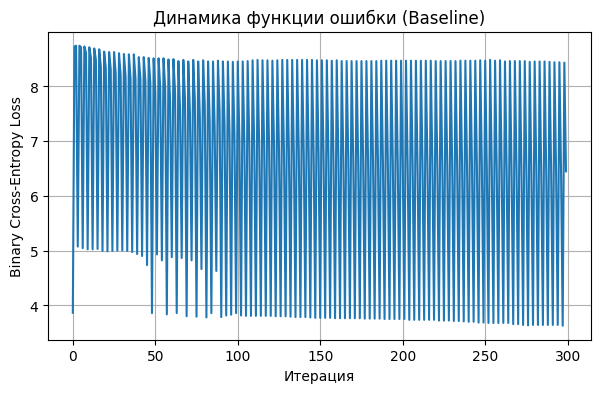

In [40]:
# Оцените качество обученной модели (точность, матрица ошибок),
# взгляните на динамику изменения функции ошибки в ходе обучения.

preds_test_baseline = model_baseline.predict(X_test_pca_raw)

acc_baseline = accuracy_score(y_test, preds_test_baseline)
prec_baseline = precision_score(y_test, preds_test_baseline)
f1_baseline = f1_score(y_test, preds_test_baseline)
rec_baseline = recall_score(y_test, preds_test_baseline)
cm_baseline = confusion_matrix(y_test, preds_test_baseline)

# Расчет False Negative Rate (вероятность пропуска бота)
fnr_baseline = None
if cm_baseline.shape[0] > 1 and cm_baseline[1].sum() > 0:
    fnr_baseline = cm_baseline[1, 0] / cm_baseline[1].sum()

print("\n--- Метрики Baseline (PCA raw) ---")
print(f"Accuracy: {np.round(acc_baseline, 4)}")
print(f"Precision: {np.round(prec_baseline, 4)}")
print(f"F1 Score: {np.round(f1_baseline, 4)}")
print(
    f"Recall (чувствительность к ботам): {np.round(rec_baseline, 4)}"
)

fnr_display = np.round(fnr_baseline * 100, 2)
print(
    f"Вероятность пропуска бота (FNR): {fnr_display}%"
)
print("Матрица ошибок:\n", cm_baseline)

# График динамики функции потерь
plt.figure(figsize=(7, 4))
plt.plot(loss_baseline)
plt.xlabel('Итерация')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Динамика функции ошибки (Baseline)')
plt.grid(True)
plt.show()

## 1.2 Анализ данных

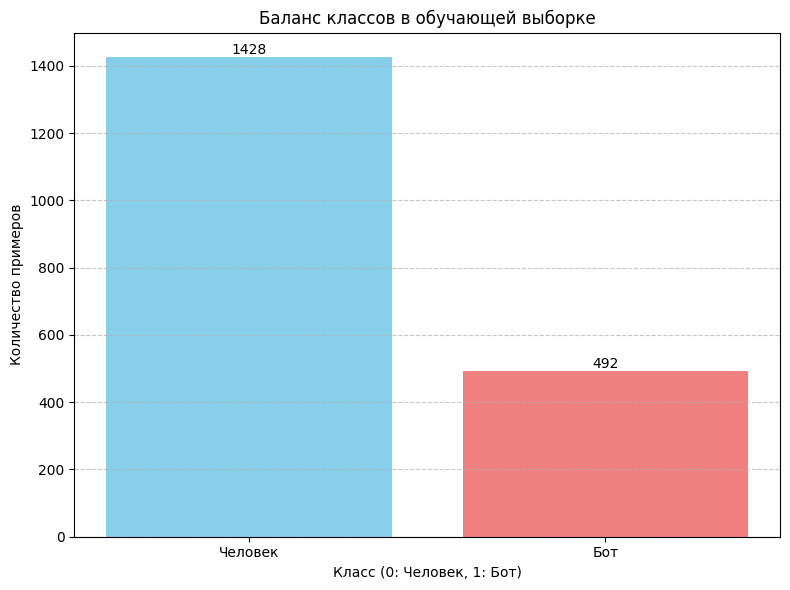

In [41]:
unique, counts = np.unique(y_train, return_counts=True)

# Создание столбчатой диаграммы
plt.figure(figsize=(8, 6))
bars = plt.bar(unique, counts, color=['skyblue', 'lightcoral'])

# Добавление названий осей и заголовка
plt.xlabel("Класс (0: Человек, 1: Бот)")
plt.ylabel("Количество примеров")
plt.title("Баланс классов в обучающей выборке")

# Добавление значений над столбцами
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.05,
        int(yval),
        ha='center',
        va='bottom'
    )

plt.xticks(unique, ['Человек', 'Бот'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [42]:
# Описательная статистика
display(x_train.describe().T)

,count,mean,std,min,25%,50%,75%,max
statuses_count,1920.0,26334.685937,60023.755799,8.000000,4379.250000,11178.000000,27743.500000,1.768111e+06
followers_count,1920.0,96541.139063,814657.644626,0.000000,1426.500000,6600.500000,27836.250000,1.848919e+07
friends_count,1920.0,1963.417708,6234.672397,0.000000,87.500000,855.500000,1963.500000,1.287360e+05
favourites_count,1920.0,10606.864063,25107.306410,0.000000,79.500000,2642.500000,10260.000000,4.627400e+05
listed_count,1920.0,746.181771,3683.017133,0.000000,42.000000,159.500000,480.000000,1.122950e+05
is_default_profile,1920.0,0.248438,0.432219,0.000000,0.000000,0.000000,0.000000,1.000000e+00
is_profile_use_background_image,1920.0,0.702604,0.457231,0.000000,0.000000,1.000000,1.000000,1.000000e+00
user_age,1920.0,3373.554167,1235.207064,726.000000,2203.500000,3814.000000,4389.250000,5.388000e+03
tweets_freq,1920.0,7.708686,22.296554,0.001752,1.489254,3.434521,7.892627,7.086617e+02
followers_growth_rate,1920.0,22.276304,170.254034,0.000000,0.469271,1.799360,7.358675,4.025515e+03


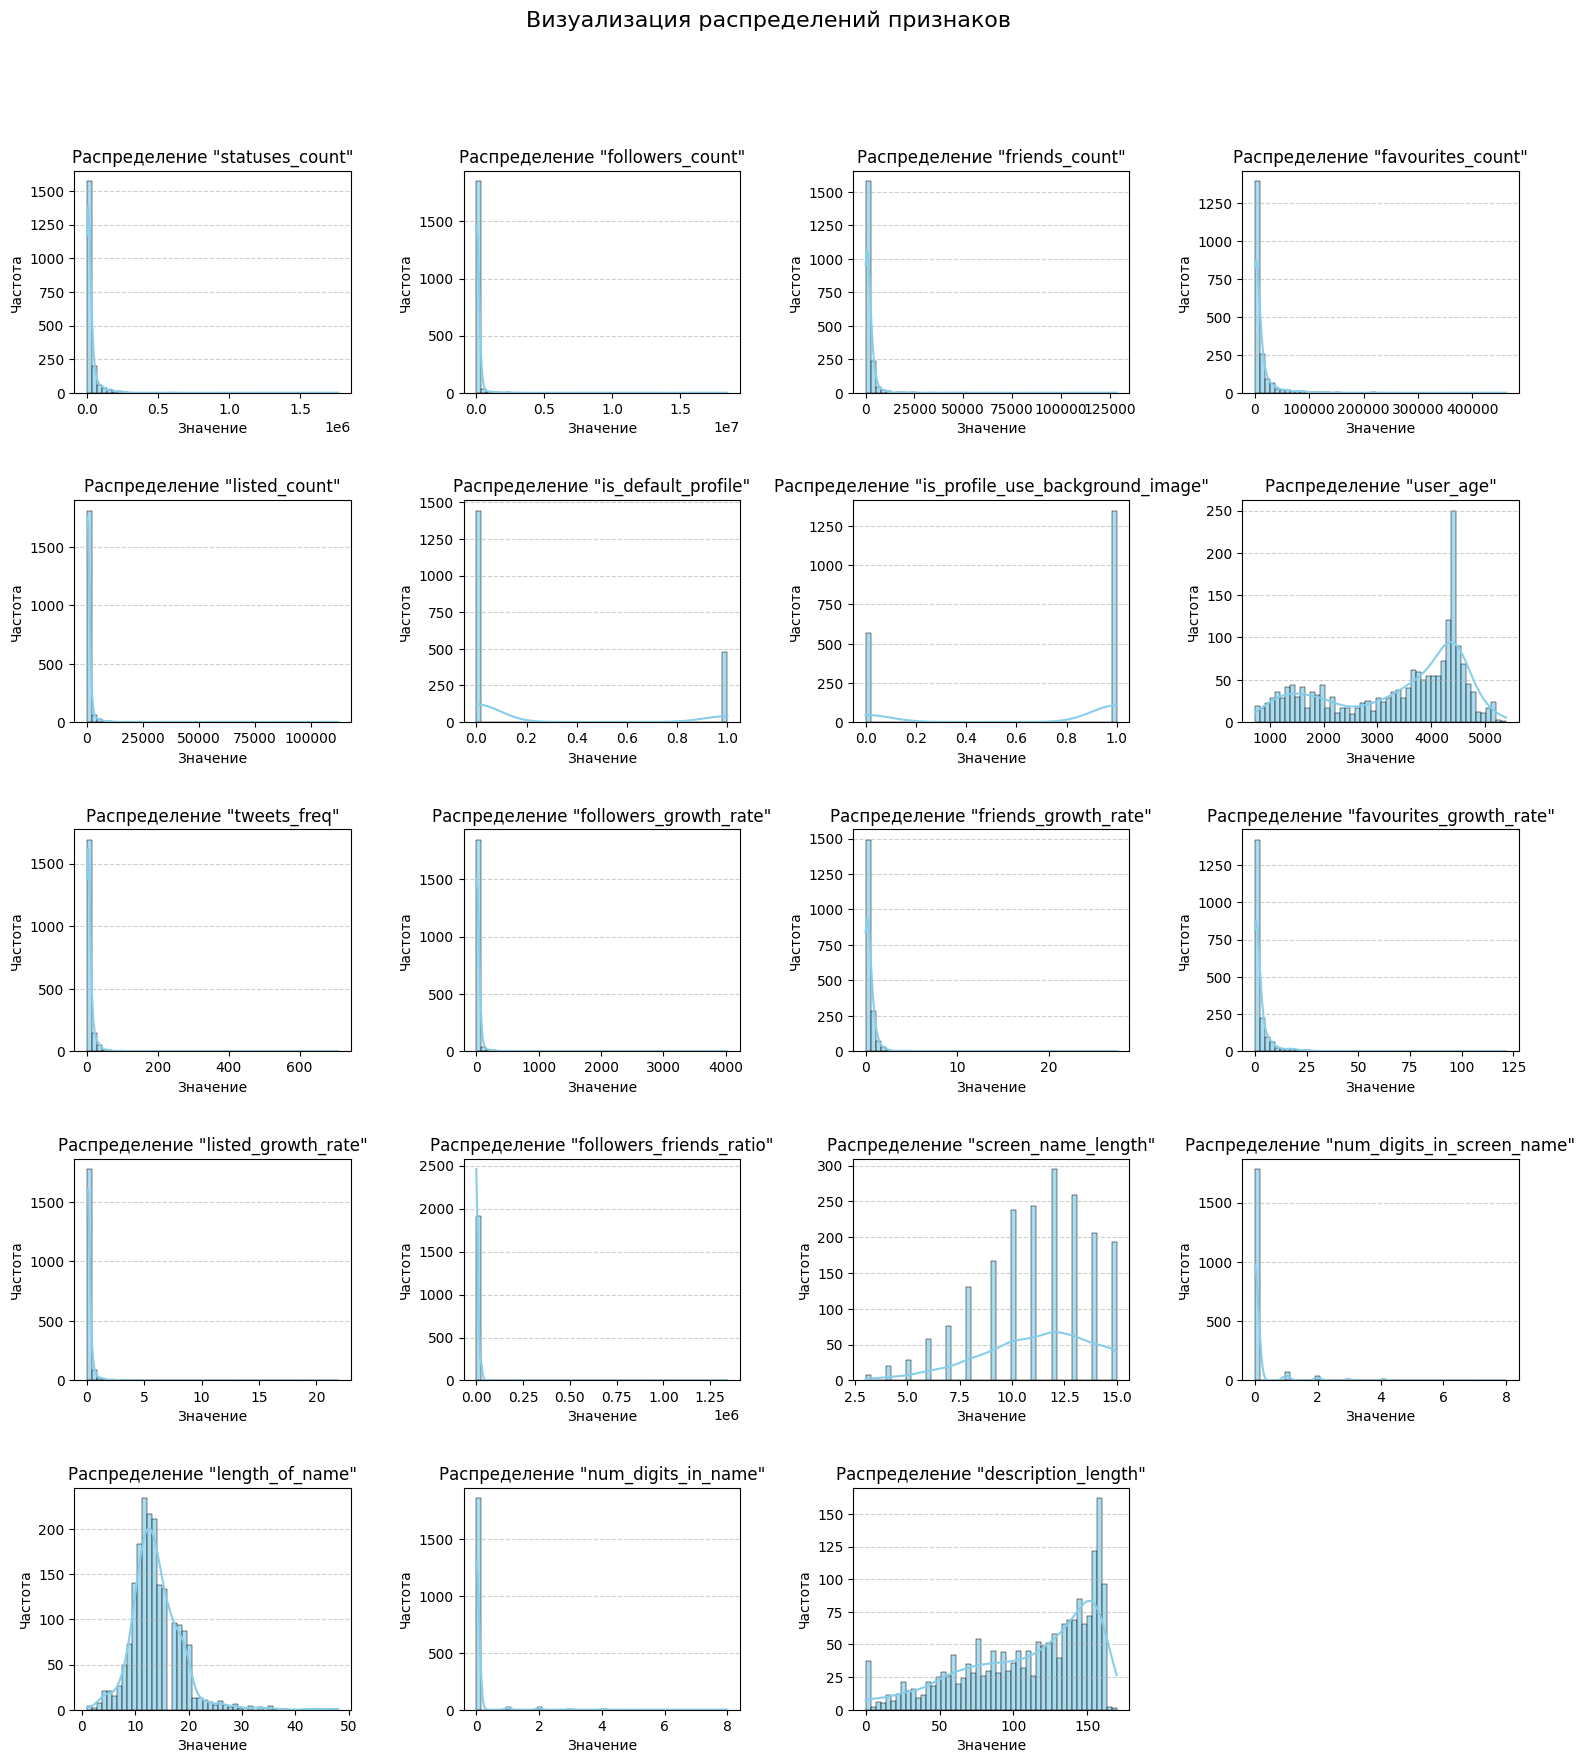

In [43]:
# Выбираем признаки для анализа (исключив целевую переменную)
feature_columns_for_plotting = x_train.columns
num_features = len(feature_columns_for_plotting)
n_cols = 4
n_rows = (num_features + n_cols - 1) // n_cols

# Визуализируем распределения признаков (гистограмма с KDE)
plt.figure(figsize=(4 * n_cols, 3.5 * n_rows))
for i, feature in enumerate(feature_columns_for_plotting):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(
        data=x_train,
        x=feature,
        kde=True,
        bins=50,
        color='skyblue',
        edgecolor='black',
        alpha=0.7
    )
    plt.title(f'Распределение "{feature}"', fontsize=12)
    plt.xlabel('Значение', fontsize=10)
    plt.ylabel('Частота', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle(
    f'Визуализация распределений признаков', fontsize=16, y=1.02
)
plt.tight_layout(pad=3.0)
plt.show()

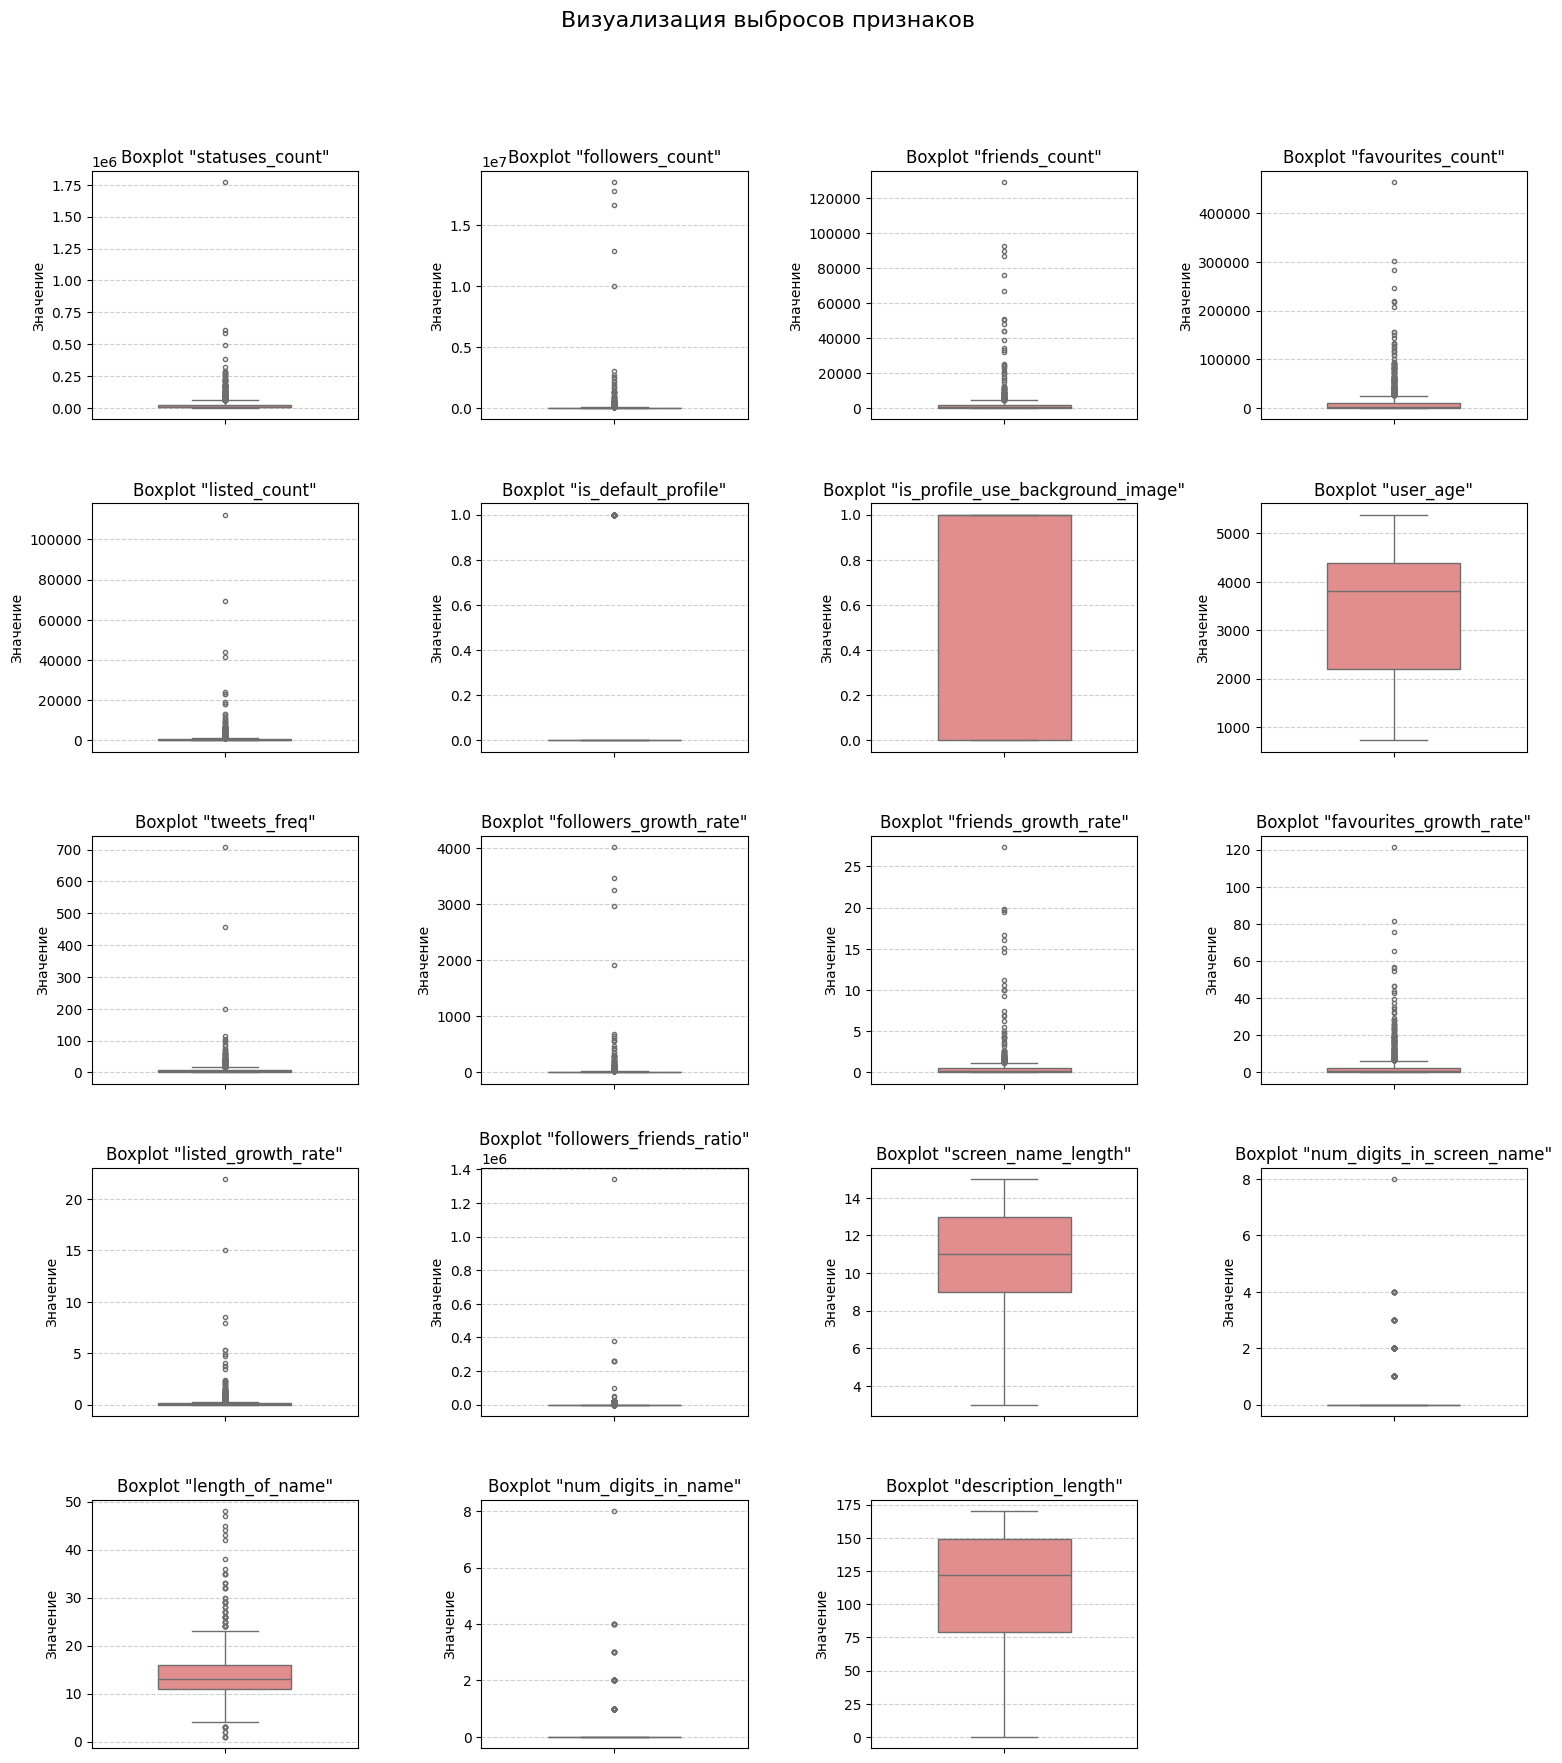

In [44]:
# Box-plot для выявления выбросов
plt.figure(figsize=(4 * n_cols, 3.5 * n_rows))
for i, feature in enumerate(feature_columns_for_plotting):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(
        data=x_train,
        y=feature,
        color='lightcoral',
        width=0.5,
        fliersize=3
    )
    plt.title(f'Boxplot "{feature}"', fontsize=12)
    plt.ylabel('Значение', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle(
    f'Визуализация выбросов признаков', fontsize=16, y=1.02
)
plt.tight_layout(pad=3.0)
plt.show()


In [ ]:
# 1. Опишите в данной клетке ваши наблюдения.
# 2. Предложите идеи к обработке/улучшению качества данных.

# Наблюдения:
# 1. Несбалансированность: Выборка является сильно несбалансированной.
#    Класс "Человек" (1428 примеров) преобладает над классом "Бот"
#    (492 примера) в соотношении примерно 3:1.
# 2. Сильное смещение (Skew): Подавляющее большинство числовых
#    признаков (счетчики, частоты, соотношения, например,
#    followers_count, friends_count, statuses_count) имеют
#    сильное правостороннее смещение (скошены), с большой
#    концентрацией значений около нуля.
# 3. Экстремальные выбросы: Графики Boxplot подтверждают наличие
#    большого количества экстремальных выбросов почти во всех
#    признаках-счетчиках и соотношениях. Для многих признаков
#    (например, followers_count, friends_count) медиана находится
#    очень низко, а выбросы простираются на несколько порядков.


# Идеи к обработке/улучшению качества данных:
# 1. Обработка выбросов: Использование винзоризации (клиппинг по
#    перцентилям, например, 1% и 99%) для ограничения экстремальных
#    значений и снижения их влияния на модель.
# 2. Трансформация распределения: Применение логарифмической
#    трансформации (np.log1p) для признаков, чтобы приблизить их
#    к более симметричному (нормальному) распределению.
# 3. Масштабирование: Применение RobustScaler или StandardScaler
#    после трансформации.
# 4. Борьба с дисбалансом классов: Использование методов
#    оверсэмплинга (например, ADASYN или SMOTE) на обучающей
#    выборке для выравнивания классов и предотвращения смещения
#    модели в сторону мажоритарного класса.
# 5. Снижение размерности: Использование PCA для уменьшения
#    числа признаков.

## 1.3 Обработка данных

In [50]:
# Реализуйте идеи по нормировке/улучшению качества данных.

def clip_by_percentiles(df, low=1.0, high=99.0):
    df_clipped = df.copy().astype(float)
    lower = df_clipped.quantile(low / 100.0)
    upper = df_clipped.quantile(high / 100.0)

    for col in df_clipped.columns:
        lo = lower[col]
        up = upper[col]
        if up > lo:  # Проверяем, что верхний перцентиль больше нижнего
            df_clipped[col] = np.clip(df_clipped[col], lo, up)

    return df_clipped

# 1. Клиппинг (1% и 99%)
X_train_clipped = clip_by_percentiles(x_train, 1, 99)
X_test_clipped = clip_by_percentiles(x_test, 1, 99)

# Функция для безопасной логарифмической трансформации log1p
def safe_log1p_train_test(X_train, X_test):
    Xtr = X_train.copy().astype(float)
    Xte = X_test.copy().astype(float)

    for col in Xtr.columns:
        min_tr = Xtr[col].min()
        shift = 0.0
        if min_tr <= -1:
            shift = -min_tr + 1e-6
        elif min_tr < 0:
            shift = -min_tr + 1e-6

        Xtr[col] = np.log1p(Xtr[col] + shift)
        Xte[col] = np.log1p(Xte[col] + shift)

    return Xtr, Xte

# 2. Логарифмическая трансформация (log1p) с использованием безопасной функции
X_train_log, X_test_log = safe_log1p_train_test(
    X_train_clipped, X_test_clipped
)

# 3. Стандартизация (RobustScaler)
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_log),
    columns=X_train_log.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_log),
    columns=X_test_log.columns
)

# 4. Борьба с дисбалансом классов (использование метода оверсэмплинга ADASYN)
print(
    f"Распределение классов в y_train до ADASYN:\n"
    f"{y_train.value_counts()}"
)
# ADASYN (Adaptive Synthetic Sampling) — это метод увеличения выборки
# для борьбы с несбалансированными классами.
# Он создает синтетические примеры для меньшинственного класса,
# основываясь на распределении данных.
sampler = ADASYN(random_state=42)
X_train_resampled, y_train_resampled = sampler.fit_resample(
    X_train_scaled, y_train
)

print(
    f"Распределение классов в y_train после ADASYN:\n"
    f"{y_train_resampled.value_counts()}"
)

X_train_scaled = X_train_resampled
y_train = y_train_resampled

# 5. PCA до 10 компонент
pca_proc = PCA(n_components=10, random_state=42)
X_train_proc = pca_proc.fit_transform(X_train_scaled)
X_test_proc = pca_proc.transform(X_test_scaled)
print(
    f"PCA: Суммарная объяснённая дисперсия: "
    f"{np.round(pca_proc.explained_variance_ratio_.sum(), 4)}"
)

Распределение классов в y_train до ADASYN:
is_bot
0         1428
1          492
Name: count, dtype: int64
Распределение классов в y_train после ADASYN:
is_bot
0         1428
1         1419
Name: count, dtype: int64
PCA: Суммарная объяснённая дисперсия: 0.9665


## 1.4 Обучение итоговой модели

In [46]:
# Обучите модель на трансформированных данных.

model_final = LogisticRegression(dim=10)
loss_final = model_final.fit(X_train_proc, y_train.values.ravel())

In [47]:
# Оцените качество обученной модели (точность, матрица ошибок).
# Взгляните (matplotlib) на динамику изменения функции ошибки
# в ходе обучения.

preds_test_final = model_final.predict(X_test_proc)

acc_final = accuracy_score(y_test, preds_test_final)
prec_final = precision_score(y_test, preds_test_final)
f1_final = f1_score(y_test, preds_test_final)
rec_final = recall_score(y_test, preds_test_final)
cm_final = confusion_matrix(y_test, preds_test_final)

# Расчет False Negative Rate (вероятность пропуска бота)
fnr_final = cm_final[1, 0] / cm_final[1].sum()

print("\n--- Метрики Final Model (Processed) ---")
print(f"Accuracy: {np.round(acc_final, 4)}")
print(f"Precision: {np.round(prec_final, 4)}")
print(f"F1 Score: {np.round(f1_final, 4)}")
print(
    f"Recall (чувствительность к ботам): {np.round(rec_final, 4)}"
)
print(
    f"Вероятность пропуска бота (FNR): "
    f"{np.round(fnr_final * 100, 2)}%"
)
print("Матрица ошибок:\n", cm_final)


--- Метрики Final Model (Processed) ---
Accuracy: 0.9854
Precision: 0.9469
F1 Score: 0.9683
Recall (чувствительность к ботам): 0.9907
Вероятность пропуска бота (FNR): 0.93%
Матрица ошибок:
 [[366   6]
 [  1 107]]


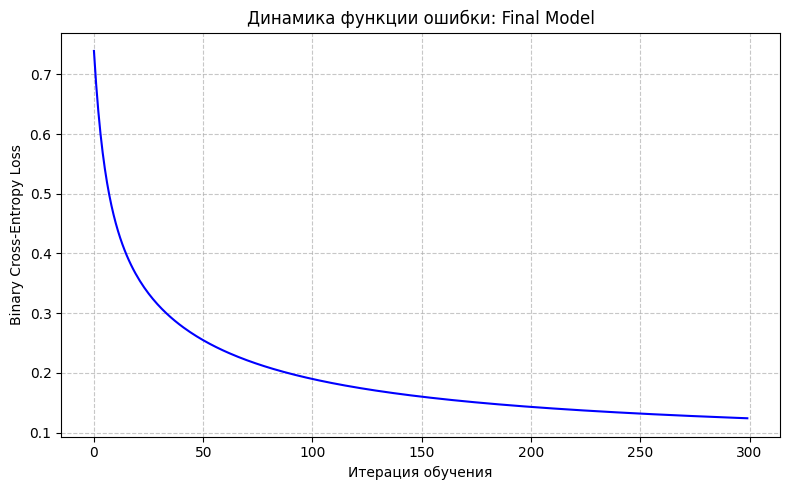

In [48]:
# График для Final модели
plt.figure(figsize=(8, 5))
plt.plot(loss_final, color='blue', linestyle='-')
plt.xlabel('Итерация обучения')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Динамика функции ошибки: Final Model')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Сравните результат с моделью из пункта 1.1.
# Опишите выводы в этой клетке.

# Вывод:
# Финальная модель, использующая обработку данных, демонстрирует
# превосходные и стабильные результаты.
# 1. Внедрение предобработки данных кардинально решило проблему
#    пропуска ботов. Recall увеличился с 22.22% до 99.07%, а
#    вероятность пропуска бота (FNR) снизилась с катастрофических
#    77.78% до минимальных 0.93%.
# 2. Финальная модель продемонстрировала устойчивое снижение
#    потерь в процессе обучения, в то время как базовая модель
#    была полностью нестабильна и не смогла обучиться.

## 2. Доп. задание (опционально)

В некоторых случаях вместо балансировки классов на уровне данных (как в ЛР1) используется балансировка на алгоритмическом уровне:
взвешиваются значения функции ошибки для разных классов (большие веса используются для редких классов, малые веса для доминирующих классов), чтобы модель во время обучения 'фокусировалась' на редких классах. В данной лабораторной работе балансировка на уровне данных возможна, однако рассмотрение алгоритмического подхода даст вам еще один полезный практический инструмент.

Модифицируйте класс логистической регрессии так, чтобы во время обучения значения функции ошибки взвешивались для разных классов.
Изменения будут представлять собой взвешивание индивидуальных градиентов (строки кода 28 и 29) для отдельных экземпляров данных.

Указание: не изменяйте код, связанный с вычислением `binary_cross_entropy`.

Сложность: энтузиаст-математик.

In [51]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def binary_cross_entropy(pred, label):
    return -np.mean(label * np.log(pred + 1e-6) + (1. - label) * np.log(1 - pred + 1e-6))

class LogisticRegression:
    def __init__(self, dim=2, class_weight=None):
        rng = np.random.default_rng(seed=0)
        self.w = rng.normal(size=(dim, 1)) / np.sqrt(dim)
        self.b = np.zeros((1,))
        self.class_weight = class_weight

    def predict(self, x, probs=False):
        # x - np.array размерности [N, dim]
        #     Массив входных признаков.
        assert x.shape[1] == self.w.shape[0], \
            "Размерность экземпляров данных не соответствует ожидаемой: " + \
            f"ожидалось x.shape[1]={self.w.shape[0]}, но было получено x.shape[1]={x.shape[1]}"
        x = x.dot(self.w) + self.b
        p = sigmoid(x)
        if probs:
            return p
        return np.array(p > 0.5).astype('int32')

    def fit(self, x, y, iters=300, lr=0.1):
        # x - np.array размерности [N, dim]
        #     Массив входных признаков.
        # y - np.array размернсоти [N]
        #     Массив меток (правильных ответов).
        assert len(x) == len(y), \
            "Количество экземпляров в массиве X не равно количеству меток в массиве Y. " + \
            f"Полученные размеры: len(X) = {len(x)}, len(Y) = {len(y)}."
        assert x.shape[1] == self.w.shape[0], \
            "Размерность экземпляров данных не соответствует ожидаемой: " + \
            f"ожидалось x.shape[1]={self.w.shape[0]}, но было получено x.shape[1]={x.shape[1]}"

        # ВНЕСИТЕ МОДИФИКАЦИИ ЗДЕСЬ.
        # ----------------------------------------------------
        y = y.reshape(-1, 1)
        loss = []

        # Создаем массив весов для каждого экземпляра данных
        # Если class_weight не задан, веса равны 1
        if self.class_weight is None:
            sample_weights = np.ones(len(y))
        else:
            sample_weights = np.ones(len(y))
            for class_label, weight in self.class_weight.items():
                sample_weights[y.flatten() == class_label] = weight

        for i in range(iters):
            preds = self.predict(x, probs=True)
            error = preds - y

            # Применяем веса к ошибке для каждого экземпляра
            weighted_error = error * sample_weights.reshape(-1, 1)

            # Обновляем веса модели, используя взвешенную ошибку
            self.w -= lr * x.T.dot(weighted_error) / y.shape[0]
            self.b -= lr * np.mean(weighted_error, axis=0)

            loss.append(binary_cross_entropy(preds, y))
        # ----------------------------------------------------
        return loss


### 2.1 Обучение без взвешивания

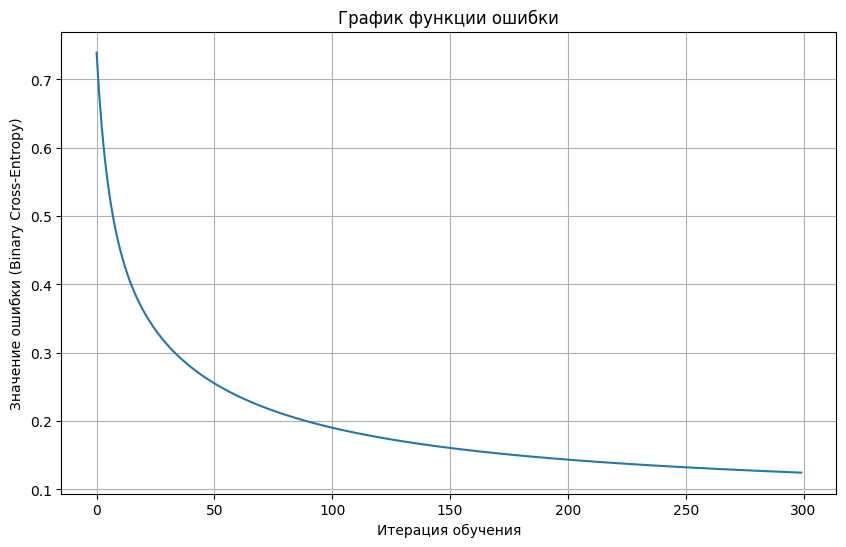

In [52]:
# Создайте и обучите новую модель на данных из пункта 1.4
# без использования взвешивания (коэффициенты 1/1).
# Сохраните возвращенные значения функции ошибки,
# визуализируйте их.

model_21 = LogisticRegression(dim=10, class_weight={0: 1.0, 1: 1.0})
loss_21 = model_21.fit(X_train_proc, y_train.values.ravel())

# Визуализация функции ошибки
plt.figure(figsize=(10, 6))
plt.plot(loss_21)
plt.title('График функции ошибки')
plt.xlabel('Итерация обучения')
plt.ylabel('Значение ошибки (Binary Cross-Entropy)')
plt.grid(True)
plt.show()


In [53]:
# Оцените качество обученной модели (точность, матрица ошибок).
# Убедитесь, что результаты схожи с результатами из пункта 1.4
# (в идеале они должны быть равны).

preds_test_21 = model_21.predict(X_test_proc)

acc_21 = accuracy_score(y_test, preds_test_21)
prec_21 = precision_score(y_test, preds_test_21)
f1_21 = f1_score(y_test, preds_test_21)
rec_21 = recall_score(y_test, preds_test_21)
cm_21 = confusion_matrix(y_test, preds_test_21)

# Расчет False Negative Rate (вероятность пропуска бота)
fnr_21 = cm_21[1, 0] / cm_21[1].sum()

print("\n--- Метрики для Пункта 2.1 (Без взвешивания) ---")
print(f"Accuracy: {np.round(acc_21, 4)}")
print(f"Precision: {np.round(prec_21, 4)}")
print(f"F1 Score: {np.round(f1_21, 4)}")
print(f"Recall (чувствительность к ботам): {np.round(rec_21, 4)}")
print(f"Вероятность пропуска бота (FNR): {np.round(fnr_21 * 100, 2)}%")
print("Матрица ошибок:\n", cm_21)


--- Метрики для Пункта 2.1 (Без взвешивания) ---
Accuracy: 0.9854
Precision: 0.9469
F1 Score: 0.9683
Recall (чувствительность к ботам): 0.9907
Вероятность пропуска бота (FNR): 0.93%
Матрица ошибок:
 [[366   6]
 [  1 107]]


### 2.2 Обучение с большим весом на классе 0

In [54]:
# Создайте и обучите новую модель на данных из пункта 1.4 с большим весом
# на классе 0 (например 10|1)
# Сохраните возвращенные значения функции ошибки.

# Класс 0 получает вес 10, класс 1 - вес 1
model_22 = LogisticRegression(dim=10, class_weight={0: 10.0, 1: 1.0})
loss_22 = model_22.fit(X_train_proc, y_train.values.ravel())

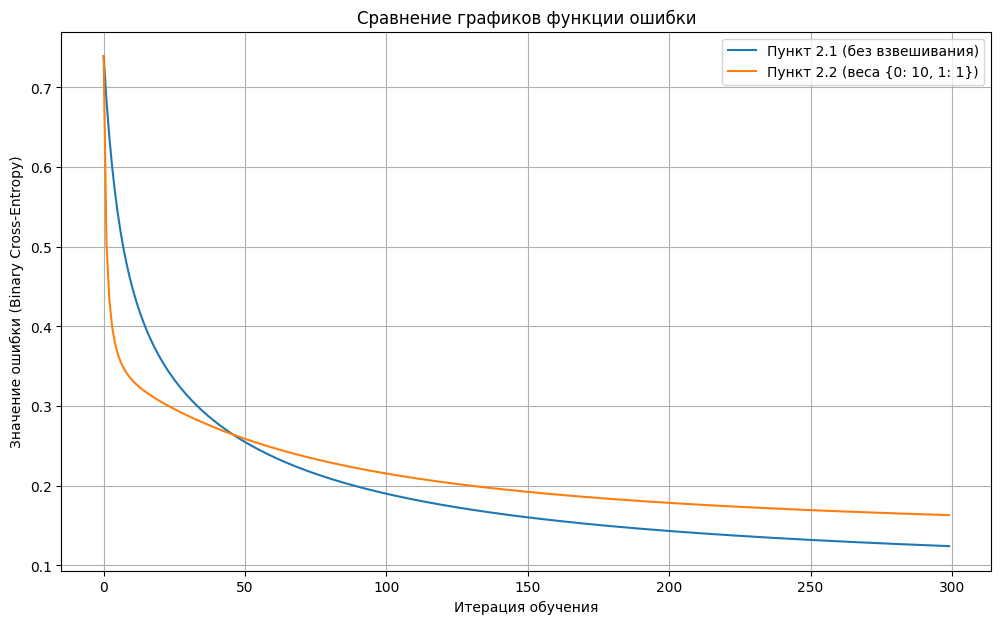

In [55]:
# Визуализируйте значения функции ошибки из пункта 2.1 и из текущего пункта.

plt.figure(figsize=(12, 7))

# График ошибки из пункта 2.1 (без взвешивания)
plt.plot(loss_21, label='Пункт 2.1 (без взвешивания)')

# График ошибки из пункта 2.2 (с весами {0: 10, 1: 1})
plt.plot(loss_22, label='Пункт 2.2 (веса {0: 10, 1: 1})')

plt.title('Сравнение графиков функции ошибки')
plt.xlabel('Итерация обучения')
plt.ylabel('Значение ошибки (Binary Cross-Entropy)')
plt.legend()
plt.grid(True)
plt.show()

In [56]:
# Оцените качество обученной модели (точность, матрица ошибок).

preds_test_22 = model_22.predict(X_test_proc)

acc_22 = accuracy_score(y_test, preds_test_22)
prec_22 = precision_score(y_test, preds_test_22)
f1_22 = f1_score(y_test, preds_test_22)
rec_22 = recall_score(y_test, preds_test_22)
cm_22 = confusion_matrix(y_test, preds_test_22)

# Расчет False Negative Rate (вероятность пропуска бота)
fnr_22 = cm_22[1, 0] / cm_22[1].sum()

print("\n--- Метрики для Пункта 2.2 (веса {0: 10, 1: 1}) ---")
print(f"Accuracy: {np.round(acc_22, 4)}")
print(f"Precision: {np.round(prec_22, 4)}")
print(f"F1 Score: {np.round(f1_22, 4)}")
print(f"Recall (чувствительность к ботам): {np.round(rec_22, 4)}")
print(f"Вероятность пропуска бота (FNR): {np.round(fnr_22 * 100, 2)}%")
print("Матрица ошибок:\n", cm_22)


--- Метрики для Пункта 2.2 (веса {0: 10, 1: 1}) ---
Accuracy: 0.9917
Precision: 0.9815
F1 Score: 0.9815
Recall (чувствительность к ботам): 0.9815
Вероятность пропуска бота (FNR): 1.85%
Матрица ошибок:
 [[370   2]
 [  2 106]]


In [ ]:
# Сравните матрицу ошибок с матрицей из пункта 2.1.

# Вывод:
# Использование взвешивания (Пункт 2.2) оказалось эффективным для улучшения
# общей производительности и, в частности, для минимизации ошибок I рода (FP).

### 2.3 Обучение с большим весом на классе 1

In [57]:
# Создайте и обучите новую модель на данных из пункта 1.4 с большим весом
# на классе 0 (например 1|10)
# Сохраните возвращенные значения функции ошибки.

# Класс 0 получает вес 1, класс 1 - вес 10
model_23 = LogisticRegression(dim=10, class_weight={0: 1.0, 1: 10.0})
loss_23 = model_23.fit(X_train_proc, y_train.values.ravel())

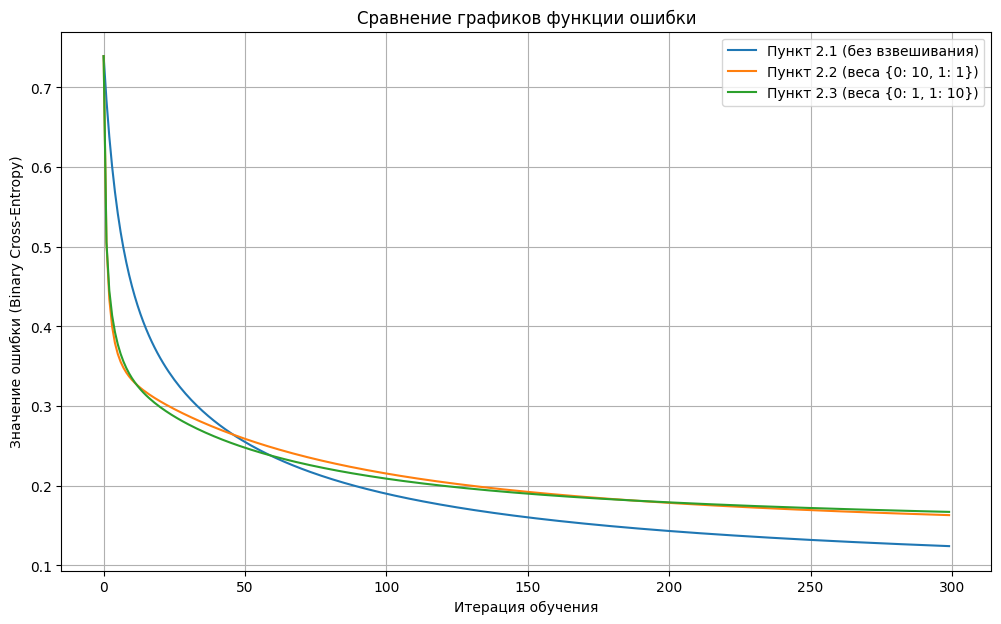

In [58]:
# Визуализируйте значения функции ошибки из пунктов 2.1, 2.2 и из текущего
# пункта.

plt.figure(figsize=(12, 7))

# График ошибки из пункта 2.1 (без взвешивания)
plt.plot(loss_21, label='Пункт 2.1 (без взвешивания)')
# График ошибки из пункта 2.2 (веса {0: 10, 1: 1})
plt.plot(loss_22, label='Пункт 2.2 (веса {0: 10, 1: 1})')
# График ошибки из пункта 2.3 (веса {0: 1, 1: 10})
plt.plot(loss_23, label='Пункт 2.3 (веса {0: 1, 1: 10})')

plt.title('Сравнение графиков функции ошибки')
plt.xlabel('Итерация обучения')
plt.ylabel('Значение ошибки (Binary Cross-Entropy)')
plt.legend()
plt.grid(True)
plt.show()

In [59]:
# Оцените качество обученной модели (точность, матрица ошибок).

preds_test_23 = model_23.predict(X_test_proc)

acc_23 = accuracy_score(y_test, preds_test_23)
prec_23 = precision_score(y_test, preds_test_23)
f1_23 = f1_score(y_test, preds_test_23)
rec_23 = recall_score(y_test, preds_test_23)
cm_23 = confusion_matrix(y_test, preds_test_23)

# Расчет False Negative Rate (вероятность пропуска бота)
fnr_23 = cm_23[1, 0] / cm_23[1].sum()

print("\n--- Метрики для Пункта 2.3 (веса {0: 1, 1: 10}) ---")
print(f"Accuracy: {np.round(acc_23, 4)}")
print(f"Precision: {np.round(prec_23, 4)}")
print(f"F1 Score: {np.round(f1_23, 4)}")
print(f"Recall (чувствительность к ботам): {np.round(rec_23, 4)}")
print(f"Вероятность пропуска бота (FNR): {np.round(fnr_23 * 100, 2)}%")
print("Матрица ошибок:\n", cm_23)


--- Метрики для Пункта 2.3 (веса {0: 1, 1: 10}) ---
Accuracy: 0.8875
Precision: 0.6688
F1 Score: 0.7985
Recall (чувствительность к ботам): 0.9907
Вероятность пропуска бота (FNR): 0.93%
Матрица ошибок:
 [[319  53]
 [  1 107]]


In [ ]:
# Сравните матрицу ошибок с матрицами из пунктов 2.1, 2.2.

# Вывод:
# Веса {0: 10, 1: 1} (Пункт 2.2): Успешно минимизировали FP и дал наилучшую
# общую производительность (минимум ошибок) по сравнению с (Пункт 2.1).
# Веса {0: 1, 1: 10} (Пункт 2.3): Успешно минимизировали FN (удержали на
# уровне 1), но ценой неприемлемого роста FP.

### 2.4 Обучение с оптимальными весами

In [60]:
# Создайте и обучите новую модель на данных из пункта 1.4.
# Найдите веса, что дают более высокую точность, нежели точность из
# пункта 1.4.
# Сохраните возвращенные значения функции ошибки.

# Изначальная точность из пункта 2.1 (без взвешивания)
initial_accuracy = acc_21
print(f"\n--- Пункт 2.4: Поиск оптимальных весов ---")
print(f"Изначальная точность (Пункт 2.1): "
      f"{np.round(initial_accuracy, 4)}")

# Список пар весов для тестирования
# Включаем уже протестированные и новые комбинации
test_weights_options = [
    (None, 'Без взвешивания'),          # Пункт 2.1
    ({0: 10.0, 1: 1.0}, 'Веса {0: 10, 1: 1}'),   # Пункт 2.2
    ({0: 1.0, 1: 10.0}, 'Веса {0: 1, 1: 10}'),   # Пункт 2.3
    ({0: 5.0, 1: 2.0}, 'Веса {0: 5, 1: 2}'),     # Новая комбинация
    ({0: 2.0, 1: 5.0}, 'Веса {0: 2, 1: 5}'),     # Новая комбинация
    ({0: 3.0, 1: 3.0}, 'Веса {0: 3, 1: 3}'),     # Пример с другими весами
    ({0: 0.5, 1: 0.5}, 'Веса {0: 0.5, 1: 0.5}')  # Пример с весами < 1
]

best_accuracy = initial_accuracy
best_model_24 = None
best_loss_24 = None
best_weights_desc = 'Без взвешивания'
best_metrics_24 = {}
best_cm_24 = None
best_fnr_24 = None

all_losses_24 = {
    'Без взвешивания': loss_21
}

for weights, desc in test_weights_options:
    print(f"\nТестируем веса: {desc}")

    # Создаем и обучаем модель
    model_current = LogisticRegression(dim=10, class_weight=weights)
    loss_current = model_current.fit(X_train_proc, y_train.values.ravel())
    all_losses_24[desc] = loss_current

    # Оцениваем качество
    preds_test_current = model_current.predict(X_test_proc)

    acc_current = accuracy_score(y_test, preds_test_current)
    prec_current = precision_score(y_test, preds_test_current)
    f1_current = f1_score(y_test, preds_test_current)
    rec_current = recall_score(y_test, preds_test_current)
    cm_current = confusion_matrix(y_test, preds_test_current)
    fnr_current = cm_current[1, 0] / cm_current[1].sum()

    # Вывод метрик внутри цикла
    print(f"  Accuracy: {np.round(acc_current, 4)}")
    print(f"  Precision: {np.round(prec_current, 4)}")
    print(f"  F1 Score: {np.round(f1_current, 4)}")
    print(f"  Recall: {np.round(rec_current, 4)}")
    print(f"  FNR: {np.round(fnr_current * 100, 2)}%")
    print(f"  Матрица ошибок:\n  {cm_current}")

    # Проверяем, является ли текущая точность лучшей
    if acc_current > best_accuracy:
        best_accuracy = acc_current
        best_model_24 = model_current
        best_loss_24 = loss_current
        best_weights_desc = desc
        best_metrics_24 = {
            'Accuracy': acc_current,
            'Precision': prec_current,
            'F1 Score': f1_current,
            'Recall': rec_current,
            'FNR': fnr_current
        }
        best_cm_24 = cm_current
        best_fnr_24 = fnr_current
        print("  >>> Новая лучшая точность найдена!")



--- Пункт 2.4: Поиск оптимальных весов ---
Изначальная точность (Пункт 2.1): 0.9854

Тестируем веса: Без взвешивания
  Accuracy: 0.9854
  Precision: 0.9469
  F1 Score: 0.9683
  Recall: 0.9907
  FNR: 0.93%
  Матрица ошибок:
  [[366   6]
 [  1 107]]

Тестируем веса: Веса {0: 10, 1: 1}
  Accuracy: 0.9917
  Precision: 0.9815
  F1 Score: 0.9815
  Recall: 0.9815
  FNR: 1.85%
  Матрица ошибок:
  [[370   2]
 [  2 106]]
  >>> Новая лучшая точность найдена!

Тестируем веса: Веса {0: 1, 1: 10}
  Accuracy: 0.8875
  Precision: 0.6688
  F1 Score: 0.7985
  Recall: 0.9907
  FNR: 0.93%
  Матрица ошибок:
  [[319  53]
 [  1 107]]

Тестируем веса: Веса {0: 5, 1: 2}
  Accuracy: 0.9917
  Precision: 0.9815
  F1 Score: 0.9815
  Recall: 0.9815
  FNR: 1.85%
  Матрица ошибок:
  [[370   2]
 [  2 106]]

Тестируем веса: Веса {0: 2, 1: 5}
  Accuracy: 0.9542
  Precision: 0.8359
  F1 Score: 0.9068
  Recall: 0.9907
  FNR: 0.93%
  Матрица ошибок:
  [[351  21]
 [  1 107]]

Тестируем веса: Веса {0: 3, 1: 3}
  Accuracy: 0

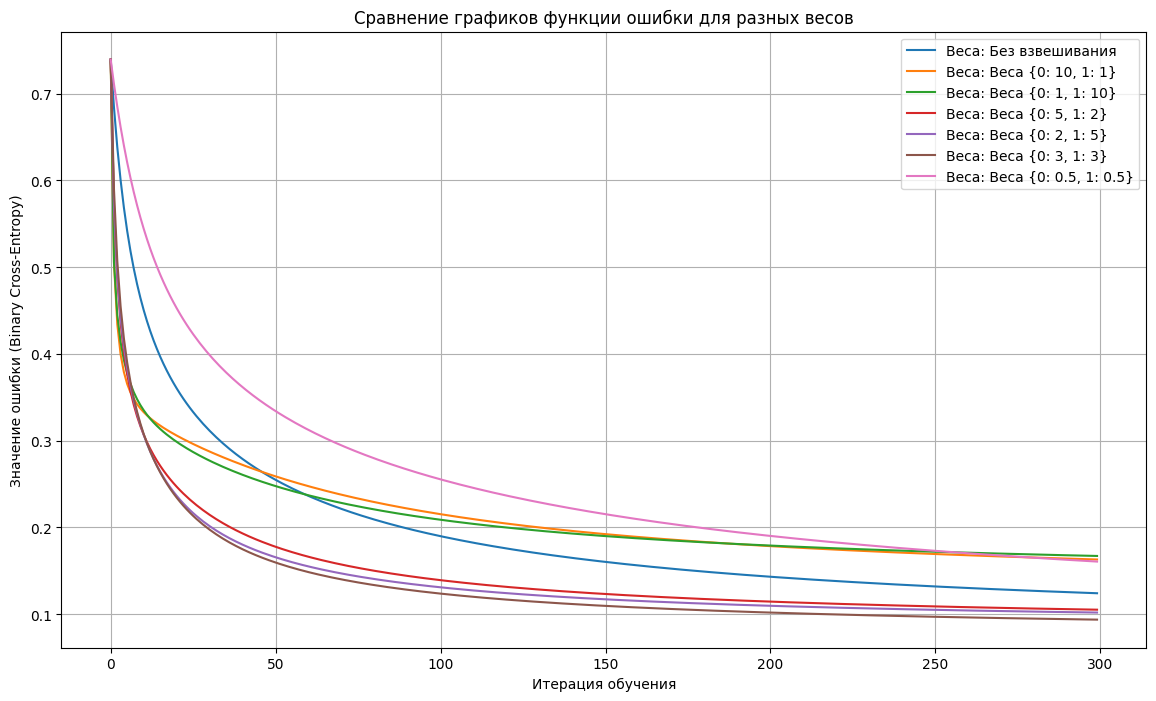

In [61]:
# Визуализируйте значения функции ошибки из пунктов 2.1, 2.2, 2.3 и из
# текущего пункта.

plt.figure(figsize=(14, 8))
for desc, losses in all_losses_24.items():
    plt.plot(losses, label=f'Веса: {desc}')
plt.title('Сравнение графиков функции ошибки для разных весов')
plt.xlabel('Итерация обучения')
plt.ylabel('Значение ошибки (Binary Cross-Entropy)')
plt.legend()
plt.grid(True)
plt.show()

In [62]:
# Оцените качество обученной модели (точность, матрица ошибок).

print("\n--- Результаты лучшей модели ---")
print(f"Лучшие веса: {best_weights_desc}")
print(f"Accuracy: {np.round(best_accuracy, 4)}")
print(f"Precision: {np.round(best_metrics_24['Precision'], 4)}")
print(f"F1 Score: {np.round(best_metrics_24['F1 Score'], 4)}")
print(f"Recall (чувствительность к ботам): "
      f"{np.round(best_metrics_24['Recall'], 4)}")
print(f"Вероятность пропуска бота (FNR): "
      f"{np.round(best_fnr_24 * 100, 2)}%")
print("Матрица ошибок:\n", best_cm_24)


--- Результаты лучшей модели ---
Лучшие веса: Веса {0: 10, 1: 1}
Accuracy: 0.9917
Precision: 0.9815
F1 Score: 0.9815
Recall (чувствительность к ботам): 0.9815
Вероятность пропуска бота (FNR): 1.85%
Матрица ошибок:
 [[370   2]
 [  2 106]]


In [ ]:
# Сравните матрицу ошибок с матрицей из пункта 2.1.

# Вывод:
# Оптимизация значительно улучшила качество классификации, сократив
# количество ложных срабатываний (FP) с 6 до 2.
# При этом наблюдается минимальное увеличение ложных пропусков (FN) с 1 до 2.